# Data Profiling - WDI African Development Indicators

This notebook performs exploratory data analysis on World Bank WDI data for African countries.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
PROJECT_ROOT = Path(r'C:\dev\africa-growth-ml')
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import load_config
from src.data import load_wdi_csv, load_wdi_metadata
from src.visualization import set_project_style, plot_missingness_heatmap, plot_feature_distributions, plot_correlation_matrix
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
set_project_style()

config = load_config(PROJECT_ROOT / 'config' / 'indicators.yaml')
print(f'Config loaded: {len(config.features)} features, {len(config.african_countries)} African countries')
print(f'Temporal splits: min_year={config.min_year}, train_end={config.train_end}, val_end={config.val_end}')

INFO: Project matplotlib style applied


INFO: Loading configuration from C:\dev\africa-growth-ml\config\indicators.yaml


INFO: Loaded 14 features, target=NY.GDP.PCAP.KD.ZG, 53 African countries


Config loaded: 14 features, 53 African countries
Temporal splits: min_year=2000, train_end=2017, val_end=2020


In [2]:
# Load raw WDI data
df = load_wdi_csv(PROJECT_ROOT / 'data' / 'raw' / 'WDICSV.csv')
print(f'Raw WDI shape: {df.shape}')
df.head()

INFO: Loading WDI data from C:\dev\africa-growth-ml\data\raw\WDICSV.csv


INFO: Raw WDI shape: (396970, 70)


Raw WDI shape: (396970, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN


In [3]:
print(f'Columns: {df.columns.tolist()}')
print(f'Dtypes:\n{df.dtypes}')

Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Dtypes:
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
2025              float64
Length: 70, dtype: object


### Interpretation
The raw WDI data is in wide format with countries as rows, indicators as rows, and years as columns. Each row represents a country-indicator combination with yearly values across columns.

## 2. African Country Filtering

In [4]:
from src.data import filter_african_countries, filter_indicators

african_df = filter_african_countries(df, african_codes=config.african_countries)
print(f'After filtering to African countries: {african_df.shape}')
print(f'Unique countries: {african_df["Country Code"].nunique()}')
print(f'Country codes: {sorted(african_df["Country Code"].unique())}')

INFO: Filtered to 77896 rows (52 countries) from 396970 total rows using ISO3 list


After filtering to African countries: (77896, 70)
Unique countries: 52
Country codes: ['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']


### Interpretation
The filtering uses an explicit ISO3 list (54 African countries) rather than substring matching on region names. This prevents the MENA substring trap where 'Middle East & North Africa' would incorrectly include non-African countries.

## 3. Indicator Coverage Analysis

In [5]:
indicator_codes = [f.code for f in config.features]
indicator_codes.append(config.target_code)
filtered = filter_indicators(african_df, indicator_codes)
print(f'After filtering to selected indicators: {filtered.shape}')
print(f'Unique indicators: {filtered["Indicator Code"].nunique()}')

INFO: Filtered to 15 indicators (780 rows)


After filtering to selected indicators: (780, 70)
Unique indicators: 15


In [6]:
# Reshape and compute coverage on training rows only
from src.data import reshape_wide_to_long, pivot_to_country_year, clean_numeric
from src.features import select_features_by_coverage

year_cols = [str(y) for y in range(config.min_year, 2025)]
long = reshape_wide_to_long(filtered, year_cols)
panel = pivot_to_country_year(long)
numeric_cols = [c for c in panel.columns if c not in ["iso3", "country_name", "year"]]
panel = clean_numeric(panel, numeric_cols)

print(f'Country-year panel shape: {panel.shape}')
print(f'Countries: {panel["iso3"].nunique()}, Years: {panel["year"].nunique()}')

INFO: Reshaped to long format: 19500 rows


INFO: Pivoted to country-year panel: (1300, 18)


Country-year panel shape: (1300, 18)
Countries: 52, Years: 25


In [7]:
# Compute coverage on training rows only (train_end = 2017)
feature_cols = [c for c in panel.columns if c not in ["iso3", "country_name", "year"]]
train_mask = panel["year"] <= config.train_end
coverage_results = {}
for col in feature_cols:
    if col in panel.columns:
        coverage = panel.loc[train_mask, col].notna().mean()
        coverage_results[col] = coverage

coverage_df = pd.DataFrame(list(coverage_results.items()), columns=["feature", "coverage"])
coverage_df = coverage_df.sort_values("coverage", ascending=False)
print(coverage_df.to_string())

                 feature  coverage
12        SP.DYN.LE00.IN  1.000000
13           SP.POP.GROW  1.000000
14     SP.URB.TOTL.IN.ZS  1.000000
1         EG.ELC.ACCS.ZS  0.982906
8         NY.GDP.PCAP.CD  0.982906
11        SL.UEM.TOTL.ZS  0.980769
4         IT.NET.USER.ZS  0.977564
0   BX.KLT.DINV.WD.GD.ZS  0.970085
9      NY.GDP.PCAP.KD.ZG  0.966880
2         FP.CPI.TOTL.ZG  0.914530
3      FS.AST.PRVT.GD.ZS  0.878205
7         NE.TRD.GNFS.ZS  0.831197
6         NE.GDI.TOTL.ZS  0.824786
5         NE.CON.GOVT.ZS  0.807692
10           SE.SEC.ENRR  0.599359


### Interpretation
Features with coverage >= 60% on training data will be kept. Features below this threshold will be dropped during feature engineering. This threshold is applied on training rows only to prevent information leakage.

## 4. Missingness Patterns

In [8]:
# Apply coverage filter to see final feature set
panel_filtered = select_features_by_coverage(panel, feature_cols, min_coverage=0.6, train_mask=train_mask)
final_features = [c for c in panel_filtered.columns if c not in ["iso3", "country_name", "year"]]
print(f'Final features ({len(final_features)}): {final_features}')

INFO: Features after coverage filter: 14 kept, 1 dropped


Final features (14): ['BX.KLT.DINV.WD.GD.ZS', 'EG.ELC.ACCS.ZS', 'FP.CPI.TOTL.ZG', 'FS.AST.PRVT.GD.ZS', 'IT.NET.USER.ZS', 'NE.CON.GOVT.ZS', 'NE.GDI.TOTL.ZS', 'NE.TRD.GNFS.ZS', 'NY.GDP.PCAP.CD', 'NY.GDP.PCAP.KD.ZG', 'SL.UEM.TOTL.ZS', 'SP.DYN.LE00.IN', 'SP.POP.GROW', 'SP.URB.TOTL.IN.ZS']


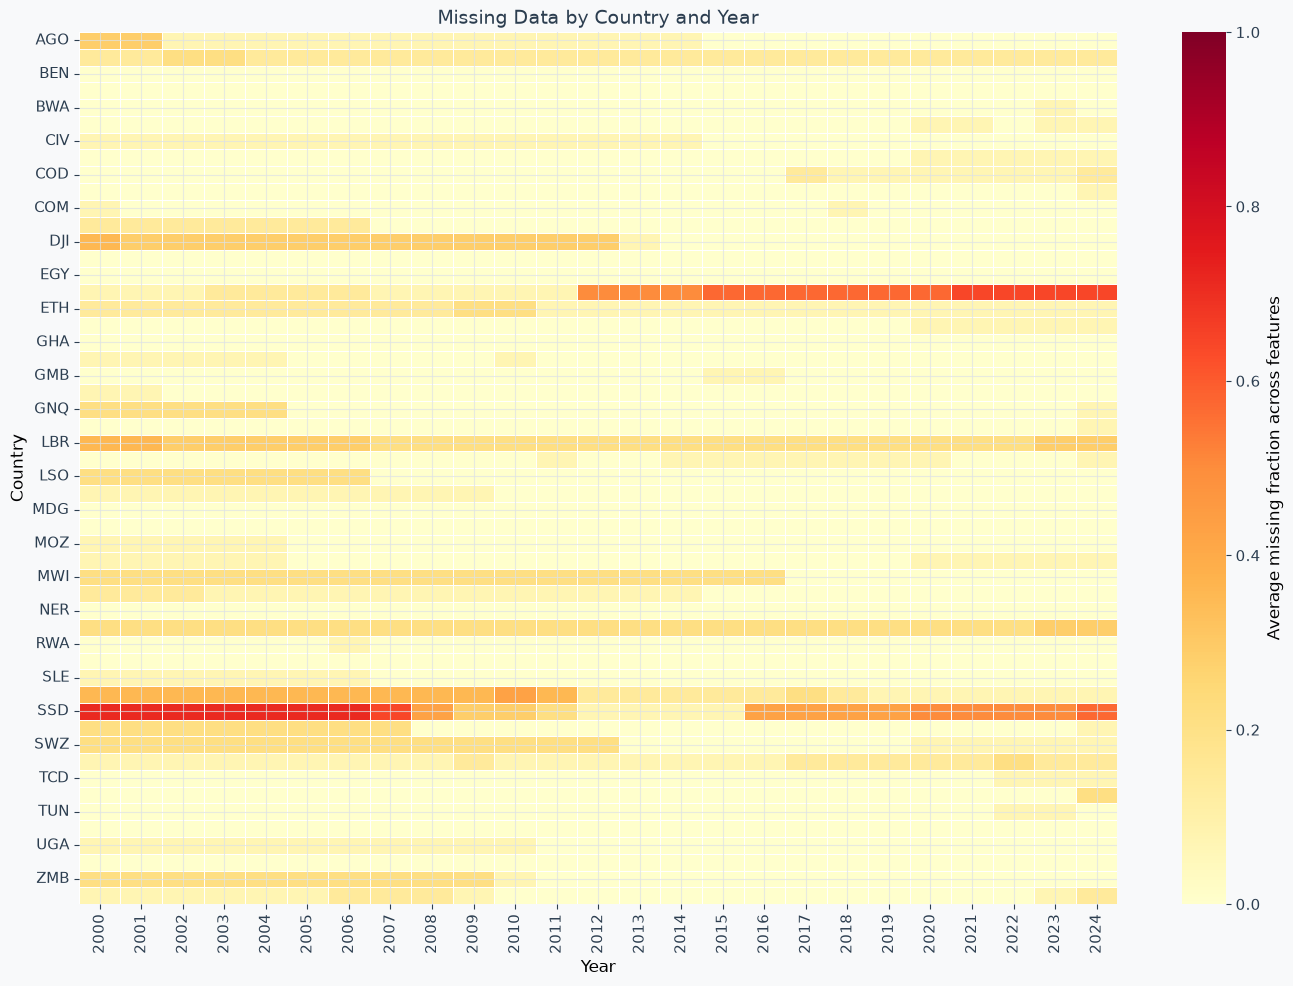

In [9]:
# Plot missingness heatmap
fig, ax = plt.subplots(figsize=(14, 10))
plot_missingness_heatmap(panel_filtered, ax=ax)
plt.show()

### Interpretation
The heatmap shows average missingness across all features by country and year. Darker red indicates higher missingness. This helps identify countries or time periods with sparse data coverage.

## 5. Feature Distributions

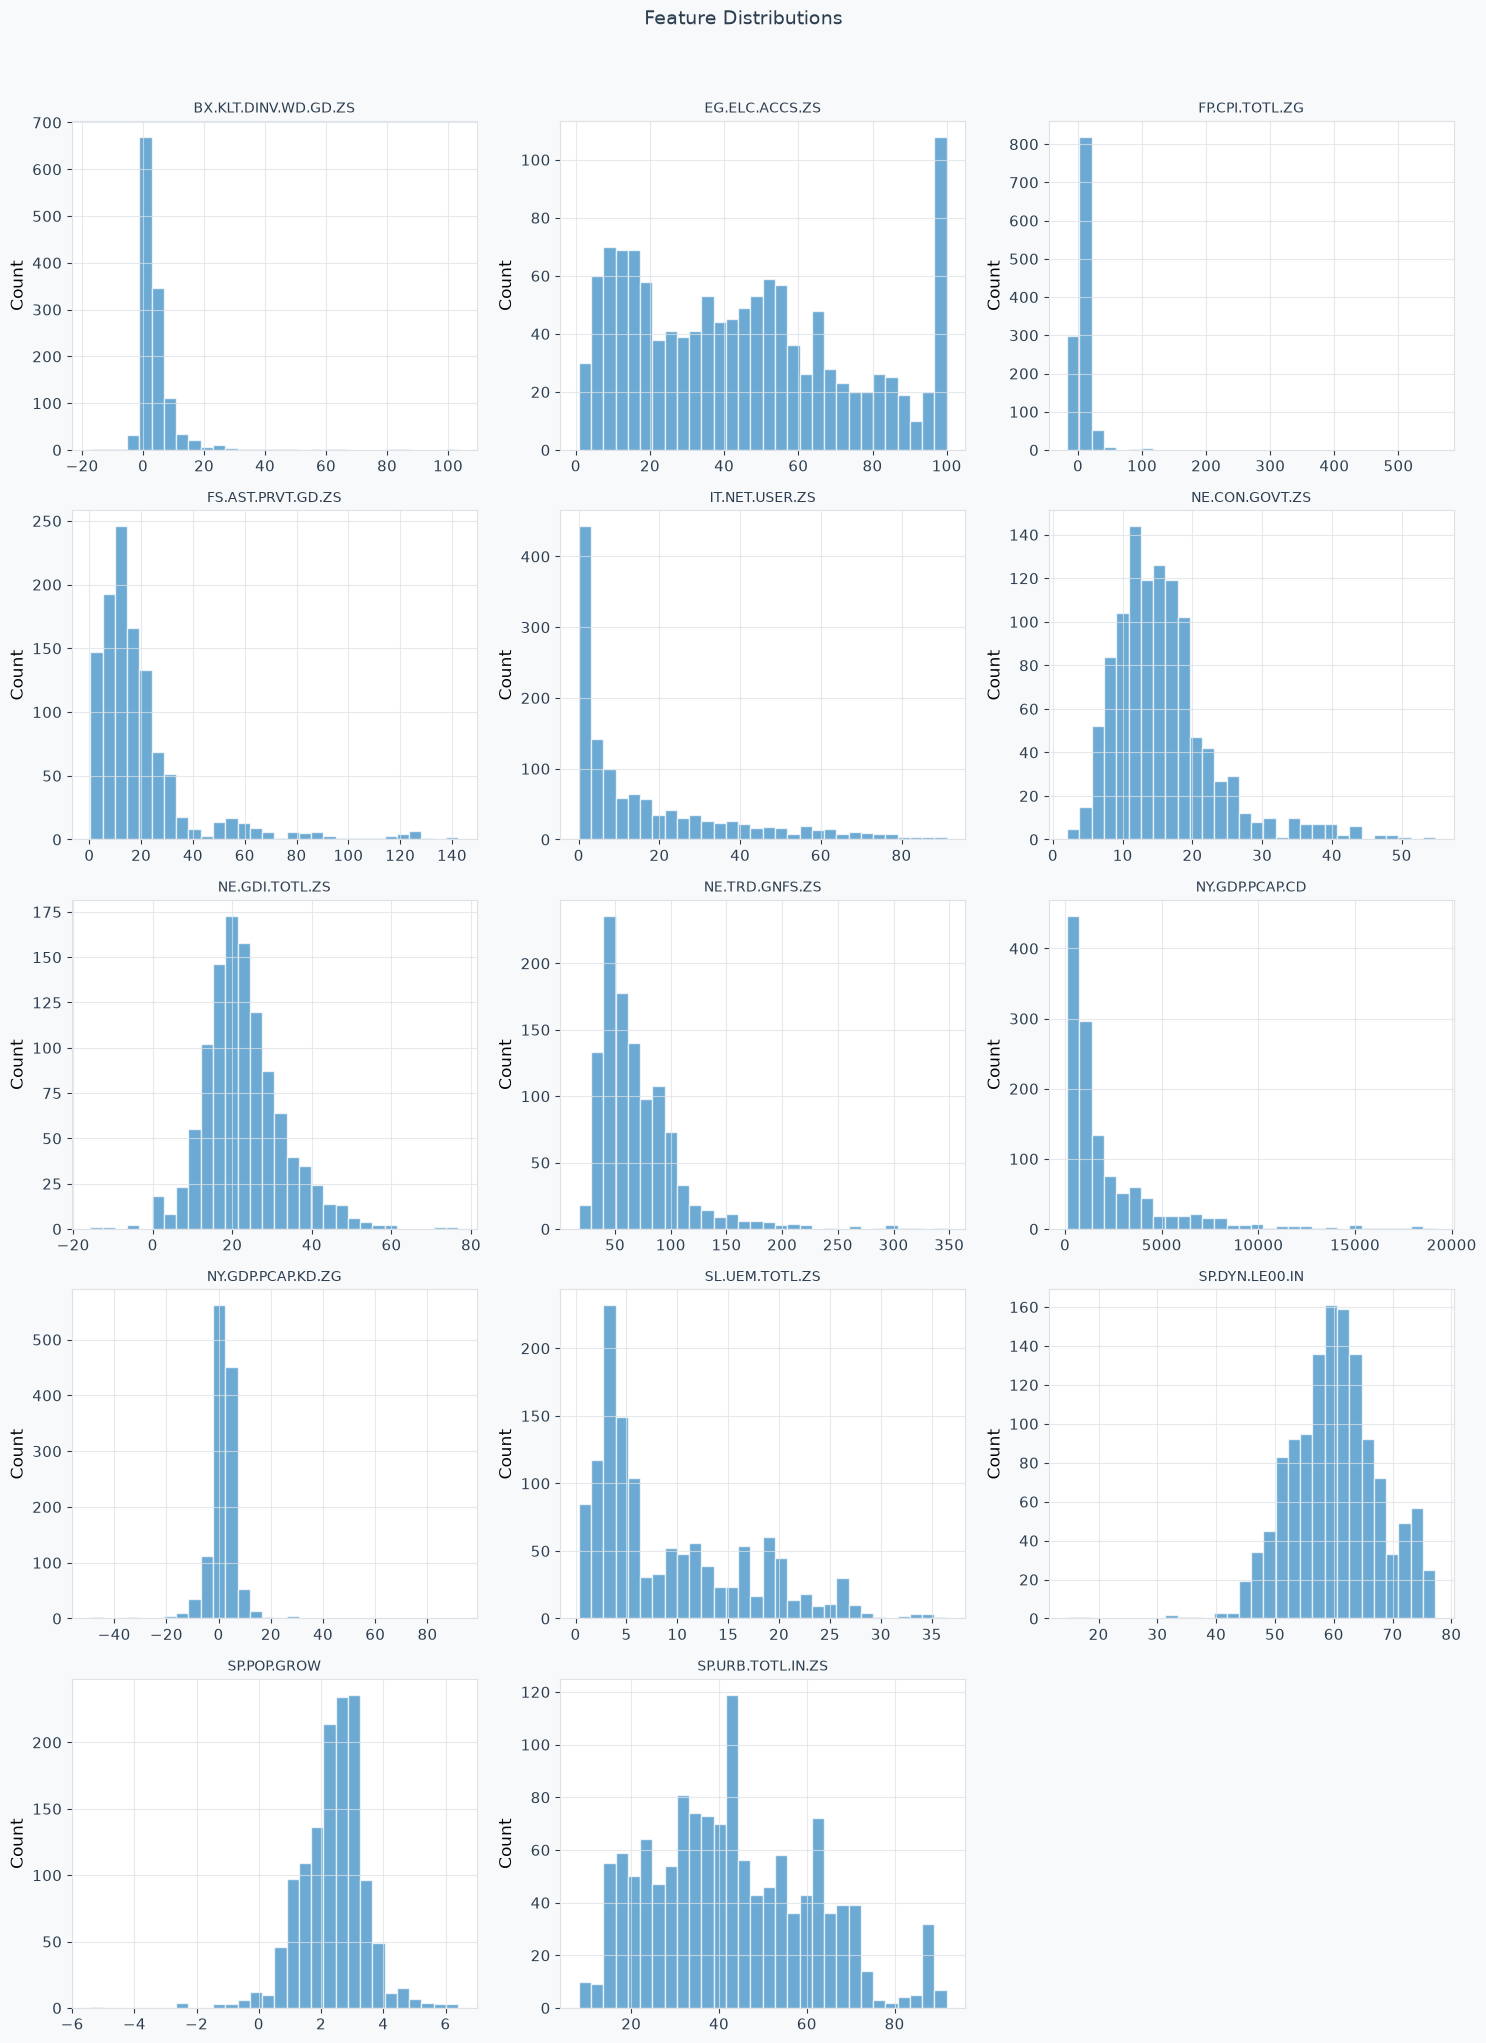

In [10]:
fig = plot_feature_distributions(panel_filtered, final_features, ncols=3)
plt.show()

### Interpretation
Histograms show the distribution of each feature. Many WDI indicators are skewed (e.g., GDP per capita, FDI). Log-transform candidates like GDP per capita (NY.GDP.PCAP.CD) will benefit from log1p scaling applied inside the sklearn pipeline.

## 6. Outlier Inspection

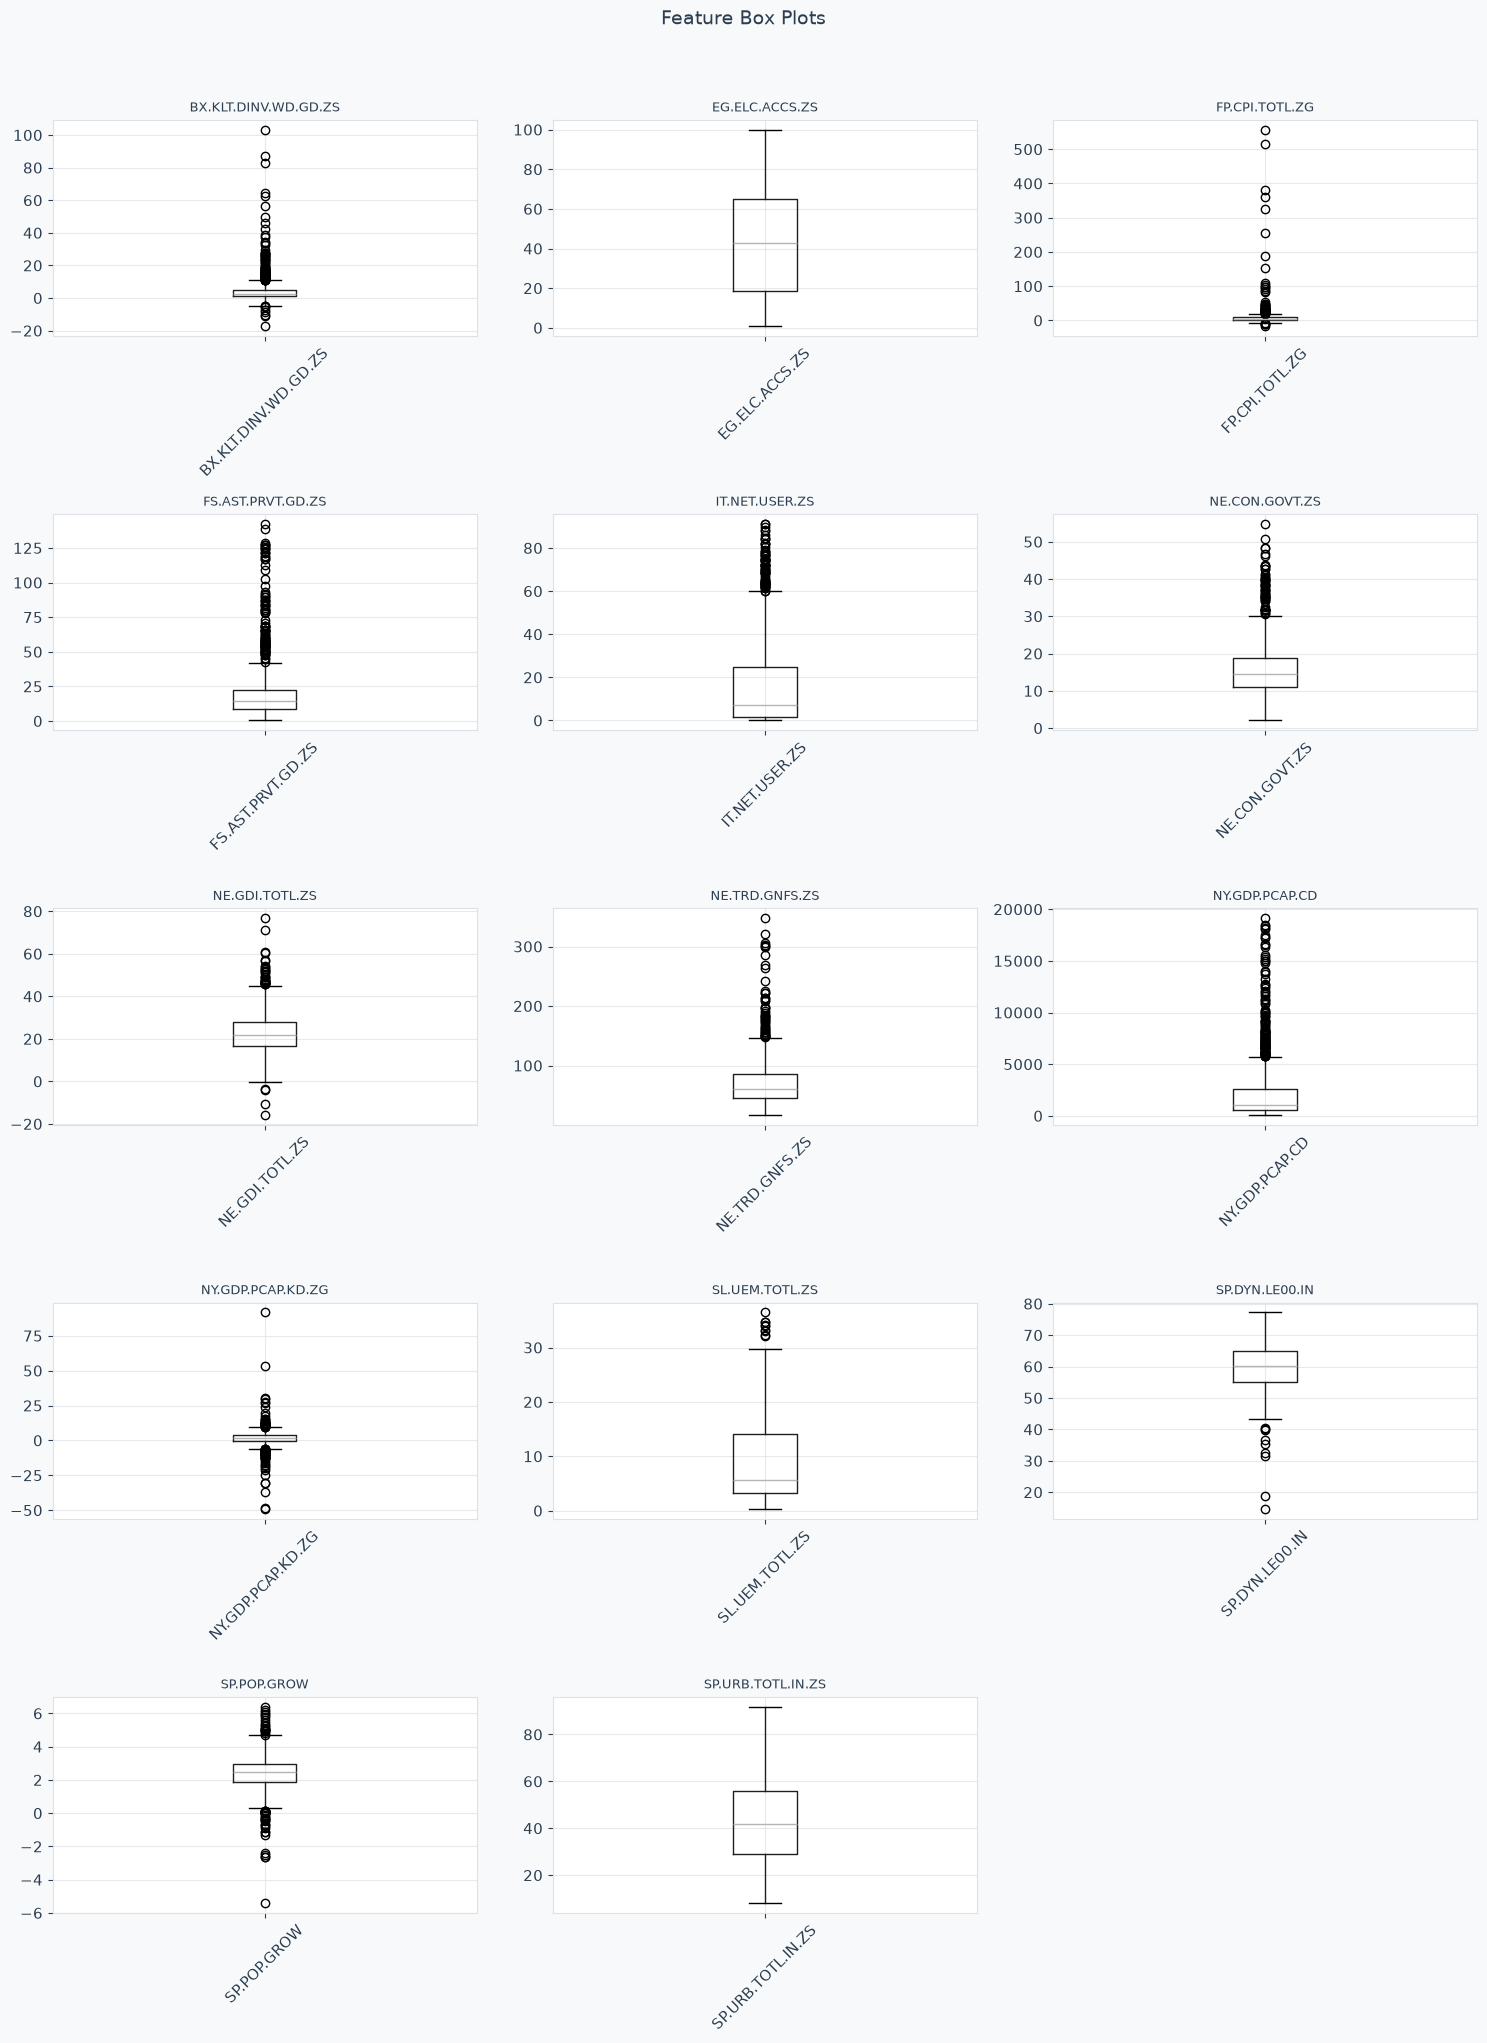

In [11]:
# Box plots for outlier detection
nrows = (len(final_features) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(final_features):
    if col in panel_filtered.columns:
        panel_filtered.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)

for j in range(len(final_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Box Plots', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [12]:
# Extreme value table
for col in final_features:
    if col in panel_filtered.columns:
        series = panel_filtered[col].dropna()
        if len(series) > 0:
            q1, q3 = series.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
            outliers = series[(series < lower) | (series > upper)]
            if len(outliers) > 0:
                print(f'{col}: {len(outliers)} outliers (IQR method), range [{series.min():.2f}, {series.max():.2f}]')

BX.KLT.DINV.WD.GD.ZS: 97 outliers (IQR method), range [-17.29, 103.34]
FP.CPI.TOTL.ZG: 90 outliers (IQR method), range [-16.86, 557.20]
FS.AST.PRVT.GD.ZS: 105 outliers (IQR method), range [0.38, 142.42]
IT.NET.USER.ZS: 74 outliers (IQR method), range [0.01, 91.20]
NE.CON.GOVT.ZS: 56 outliers (IQR method), range [2.05, 54.80]
NE.GDI.TOTL.ZS: 35 outliers (IQR method), range [-15.68, 76.78]
NE.TRD.GNFS.ZS: 49 outliers (IQR method), range [17.40, 347.72]
NY.GDP.PCAP.CD: 127 outliers (IQR method), range [109.59, 19141.51]
NY.GDP.PCAP.KD.ZG: 106 outliers (IQR method), range [-49.13, 91.78]
SL.UEM.TOTL.ZS: 9 outliers (IQR method), range [0.32, 36.47]
SP.DYN.LE00.IN: 9 outliers (IQR method), range [14.66, 77.24]
SP.POP.GROW: 51 outliers (IQR method), range [-5.42, 6.41]


### Interpretation
Outliers are identified using the IQR method. Extreme values in indicators like inflation (FP.CPI.TOTL.ZG) or FDI (BX.KLT.DINV.WD.GD.ZS) may represent real economic events (hyperinflation, large investment flows) rather than data errors.

## 7. Correlation Matrix

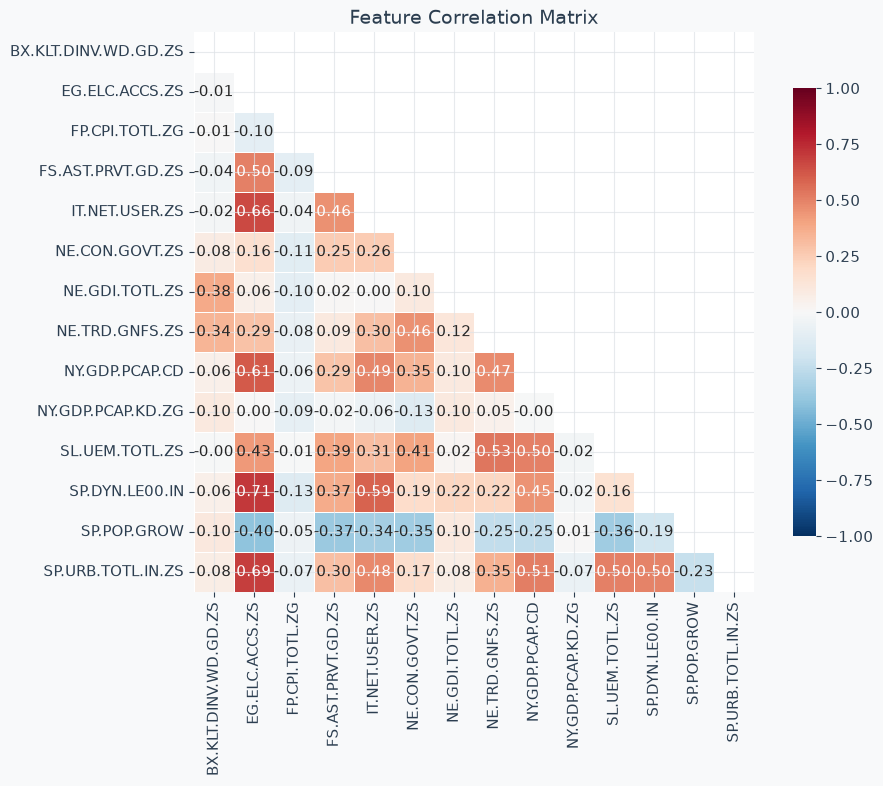

In [13]:
fig = plot_correlation_matrix(panel_filtered, final_features)
plt.show()

### Interpretation
The correlation matrix shows relationships between features. Highly correlated features (|r| > 0.8) may contain redundant information. This informs feature selection for modeling.

## 8. Final Feature Set Decision

In [14]:
# Summary of feature selection
dropped = [c for c in feature_cols if c not in final_features]
print(f'Features kept ({len(final_features)}):')
for f in final_features:
    print(f'  - {f}')
print(f'\nFeatures dropped ({len(dropped)}):')
for f in dropped:
    print(f'  - {f}')

Features kept (14):
  - BX.KLT.DINV.WD.GD.ZS
  - EG.ELC.ACCS.ZS
  - FP.CPI.TOTL.ZG
  - FS.AST.PRVT.GD.ZS
  - IT.NET.USER.ZS
  - NE.CON.GOVT.ZS
  - NE.GDI.TOTL.ZS
  - NE.TRD.GNFS.ZS
  - NY.GDP.PCAP.CD
  - NY.GDP.PCAP.KD.ZG
  - SL.UEM.TOTL.ZS
  - SP.DYN.LE00.IN
  - SP.POP.GROW
  - SP.URB.TOTL.IN.ZS

Features dropped (1):
  - SE.SEC.ENRR


### Summary
The final feature set is determined by coverage analysis (>=60% on training data). The selected features will be used for model training in Phase 2. Log-transform candidates (NY.GDP.PCAP.CD) will be transformed inside the sklearn pipeline via FunctionTransformer.